Initiating fast Grid Search to tune Random Forest hyperparameters...
Optimal Parameters Found: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



### Copy and paste this Markdown Table directly into your report:

| Algorithm Candidate   | Target Class   |   Precision |   Recall |   F1-Score | Overall Accuracy   |
|:----------------------|:---------------|------------:|---------:|-----------:|:-------------------|
| Logistic Regression   | Low            |        0.82 |     0.68 |       0.74 | 56.2%              |
|                       | Medium         |        0.52 |     0.58 |       0.54 |                    |
|                       | High           |        0.48 |     0.81 |       0.6  |                    |
|                       | Critical       |        0.5  |     0.34 |       0.41 |                    |
| Decision Tree         | Low            |        0.75 |     0.81 |       0.78 | 63.2%              |
|                       | Medium         |        0.53 |     0.5  |       0.51 |                    |
|                       | High           |        0.71 |     0.65 |       0.68 |                    |
|             

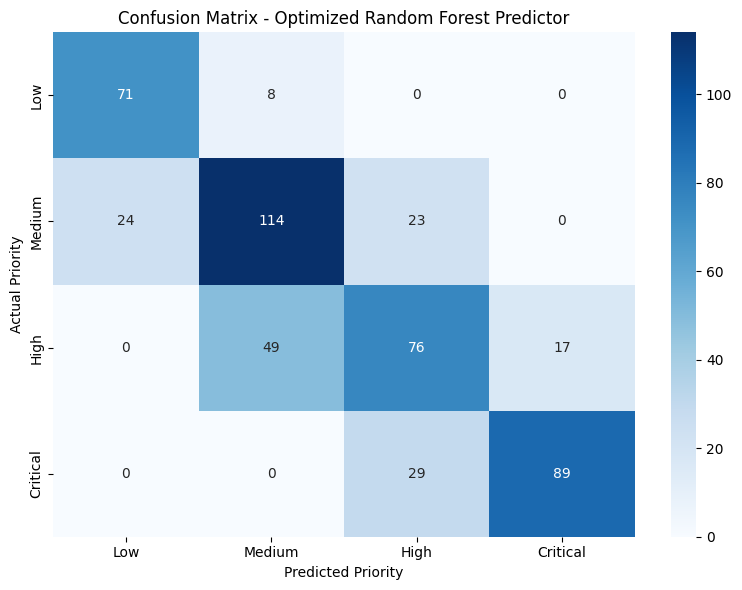


Processing complete! Downloading assets...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from google.colab import files

# 1. GENERATE SYNTHETIC DATASET (WITH BRANCH LOCATIONS)
np.random.seed(42)
n_samples = 2500

departments = ['HR', 'Finance', 'IT', 'Sales', 'Marketing', 'Operations']
categories = ['Software', 'Hardware', 'Network', 'Access/Login', 'Security']
devices = ['Laptop', 'Desktop', 'Mobile', 'Printer', 'Server', 'None']
locations = ['Kandy', 'Colombo']

data = {
    'Department': np.random.choice(departments, n_samples),
    'Issue_Category': np.random.choice(categories, n_samples),
    'Device_Type': np.random.choice(devices, n_samples),
    'Affected_Users': np.random.randint(1, 50, n_samples),
    'Business_Critical': np.random.choice(['Yes', 'No'], n_samples, p=[0.2, 0.8]),
    'Office_Location': np.random.choice(locations, n_samples)
}
df = pd.DataFrame(data)

# Logical rule-based mapping to determine ground-truth priority
def assign_priority(row):
    # INSTANT OVERRIDE RULE: Server Security issues are always Critical or High
    if row['Issue_Category'] == 'Security' and row['Device_Type'] == 'Server':
        if row['Affected_Users'] > 10 or row['Business_Critical'] == 'Yes':
            return 'Critical'
        return 'High'

    # Standard logical scoring for all other combinations
    score = 0
    if row['Business_Critical'] == 'Yes': score += 4
    if row['Affected_Users'] > 20: score += 3
    elif row['Affected_Users'] > 5: score += 1
    if row['Issue_Category'] in ['Network', 'Security']: score += 2

    score += np.random.randint(-1, 2) # Noise variance
    if score >= 6: return 'Critical'
    elif score >= 4: return 'High'
    elif score >= 2: return 'Medium'
    else: return 'Low'

df['Priority'] = df.apply(assign_priority, axis=1)

# =====================================================================
# ADDED FEATURE ENGINEERING: IMPACT SCORE
# =====================================================================
# Creates a combined interaction feature tracking the true scale of impact.
df['Impact_Score'] = df['Affected_Users'] * df['Business_Critical'].map({'Yes': 1.5, 'No': 0.5})

# 2. DATA PREPROCESSING & LABEL ENCODING
encoders = {}
categorical_cols = ['Department', 'Issue_Category', 'Device_Type', 'Business_Critical', 'Office_Location']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop('Priority', axis=1)
y = df['Priority']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# ADDED OPTIMIZATION: FAST HYPERPARAMETER TUNING & BALANCED CLASS WEIGHTS
# =====================================================================
# Trimmed grid configuration to prevent Colab process hangs
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'class_weight': ['balanced']
}

print("Initiating fast Grid Search to tune Random Forest hyperparameters...")
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)
grid_search.fit(X_train, y_train)
optimized_rf = grid_search.best_estimator_
print(f"Optimal Parameters Found: {grid_search.best_params_}\n")

# Re-evaluating performance with optimized algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': optimized_rf
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results.append({'Model': name, 'Accuracy': acc, 'Weighted F1-Score': f1})

results_df = pd.DataFrame(results)

# 3. DETAILED COMPARATIVE MATRIX GENERATION
target_names = ['Low', 'Medium', 'High', 'Critical']
matrix_rows = []

for name, model in models.items():
    preds = model.predict(X_test)
    report = classification_report(y_test, preds, target_names=target_names, output_dict=True)

    for i, label in enumerate(target_names):
        is_first_row = (i == 0)
        matrix_rows.append({
            "Algorithm Candidate": name if is_first_row else "",
            "Target Class": label,
            "Precision": round(report[label]['precision'], 2),
            "Recall": round(report[label]['recall'], 2),
            "F1-Score": round(report[label]['f1-score'], 2),
            "Overall Accuracy": f"{round(report['accuracy'] * 100, 1)}%" if is_first_row else ""
        })

detailed_matrix_df = pd.DataFrame(matrix_rows)
detailed_matrix_df.to_csv('model_comparison.csv', index=False)

print("\n### Copy and paste this Markdown Table directly into your report:\n")
print(detailed_matrix_df.to_markdown(index=False))
print("\n" + "="*50 + "\n")

# 4. GENERATE CONFUSION MATRIX VISUAL
best_model = models['Random Forest']
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds, labels=['Low', 'Medium', 'High', 'Critical'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High', 'Critical'],
            yticklabels=['Low', 'Medium', 'High', 'Critical'])
plt.title('Confusion Matrix - Optimized Random Forest Predictor')
plt.ylabel('Actual Priority')
plt.xlabel('Predicted Priority')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# 5. SAVE ENCODERS AND BEST MODEL
joblib.dump(best_model, 'priority_model.pkl')
joblib.dump(encoders, 'encoders.pkl')

print("\nProcessing complete! Downloading assets...")
files.download('priority_model.pkl')
files.download('encoders.pkl')
files.download('model_comparison.csv')
files.download('confusion_matrix.png')

In [ ]:
df.head(10)

,Department,Issue_Category,Device_Type,Affected_Users,Business_Critical,Office_Location,Priority,Impact_Score
0,5,1,3,3,0,0,Low,1.5
1,3,3,0,42,0,1,High,21.0
2,2,1,1,21,1,0,Critical,31.5
3,3,4,3,35,0,0,Medium,17.5
4,3,3,5,41,1,1,Critical,61.5
5,0,1,0,40,0,1,High,20.0
6,2,2,5,3,0,1,Low,1.5
7,2,4,3,25,0,1,High,12.5
8,2,4,3,45,0,1,Medium,22.5
9,3,4,0,38,0,0,Medium,19.0
